In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import RobustScaler

In [ ]:
df = pd.read_csv("data_cleaned.csv")
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,...,yr_built,yr_renovated,street,city,year,month,day,zipcode,city_clean,city_encoded
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,...,1955,2005,18810 Densmore Ave N,Shoreline,2014,5,2,98133,Shoreline,420396.789025
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,...,1921,0,709 W Blaine St,Seattle,2014,5,2,98119,Seattle,579837.467282
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,...,1966,0,26206-26214 143rd Ave SE,Kent,2014,5,2,98042,Kent,439492.452325
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,...,1963,0,857 170th Pl NE,Bellevue,2014,5,2,98008,Bellevue,847180.662995
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,...,1976,1992,9105 170th Ave NE,Redmond,2014,5,2,98052,Redmond,667649.534728


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          4600 non-null   float64
 1   bedrooms       4600 non-null   float64
 2   bathrooms      4600 non-null   float64
 3   sqft_living    4600 non-null   int64  
 4   sqft_lot       4600 non-null   int64  
 5   floors         4600 non-null   float64
 6   waterfront     4600 non-null   int64  
 7   view           4600 non-null   int64  
 8   condition      4600 non-null   int64  
 9   sqft_above     4600 non-null   int64  
 10  sqft_basement  4600 non-null   int64  
 11  yr_built       4600 non-null   int64  
 12  yr_renovated   4600 non-null   int64  
 13  street         4600 non-null   object 
 14  city           4600 non-null   object 
 15  year           4600 non-null   int64  
 16  month          4600 non-null   int64  
 17  day            4600 non-null   int64  
 18  zipcode 

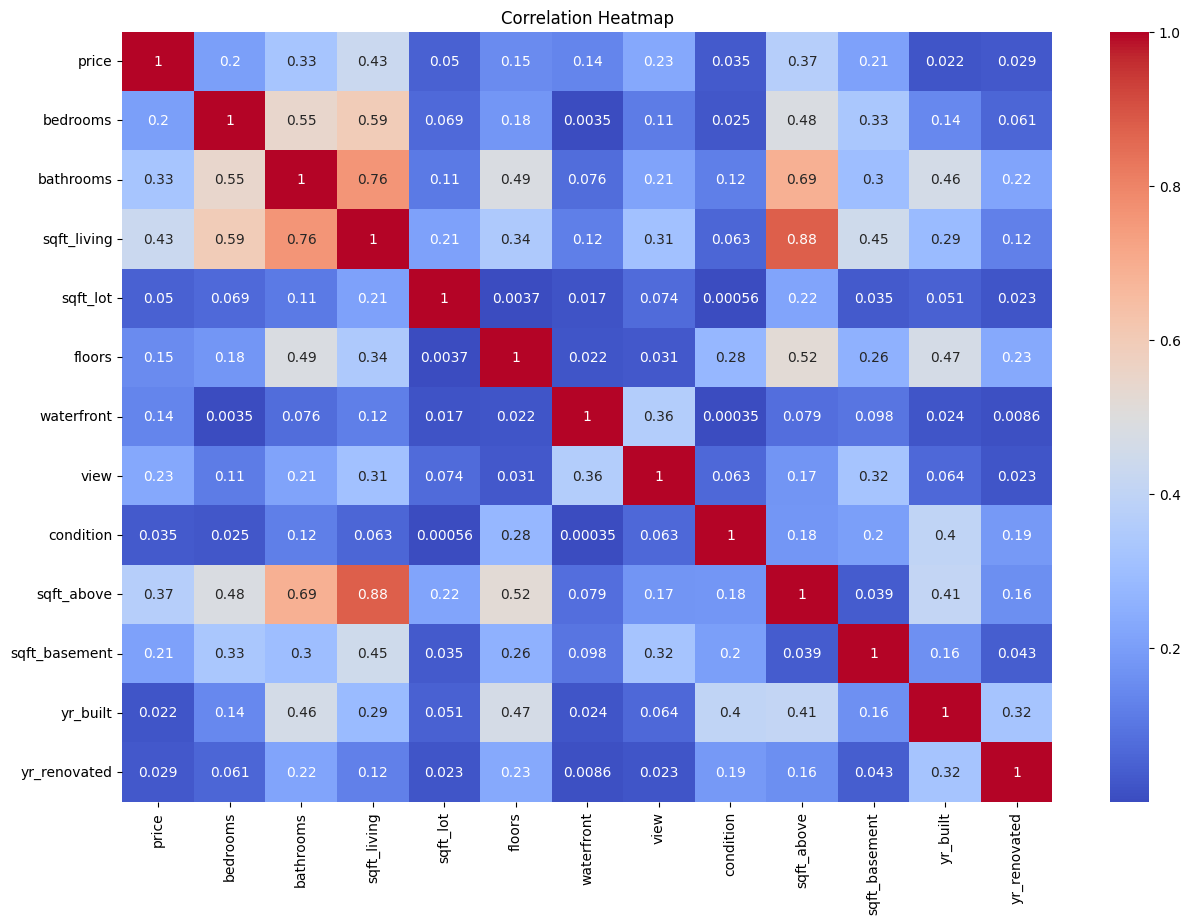

In [ ]:
non_targets = ['day','month','year','zipcode','city_encoded']
numerical_cols = df.select_dtypes(include=["number"]).drop(columns=non_targets)
correlation = numerical_cols.corr().abs()

plt.figure(figsize=(15, 10))
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

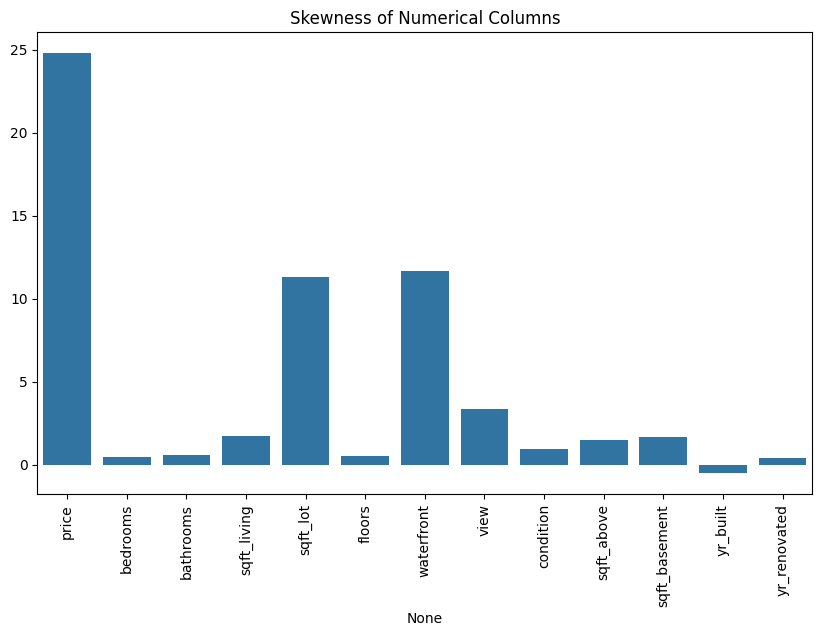

In [ ]:
skewness = numerical_cols.skew()
plt.figure(figsize=(10, 6))
sns.barplot(x=skewness.index, y=skewness.values)
plt.title("Skewness of Numerical Columns")
plt.xticks(rotation=90)
plt.show()


In [ ]:
print(skewness.to_dict())

{'price': 24.790932561757053, 'bedrooms': 0.4564466330191457, 'bathrooms': 0.6160327233508812, 'sqft_living': 1.723513270622118, 'sqft_lot': 11.307138748782643, 'floors': 0.5514406463488161, 'waterfront': 11.682900924983505, 'view': 3.341586380673694, 'condition': 0.9590676635009114, 'sqft_above': 1.4942107479829443, 'sqft_basement': 1.6427321922167097, 'yr_built': -0.5021551899878874, 'yr_renovated': 0.38591870088297575}


In [ ]:
target_features = ['price','sqft_living','sqft_lot','sqft_above','sqft_basement']
for col in target_features:
  df[f'log_{col}'] = np.log1p(df[col]).abs()

log_numerical_cols = df.select_dtypes(include=["number"]).drop(columns=non_targets)
binary_col = ['waterfront']
scale_features = log_numerical_cols.drop(columns=binary_col+ target_features+['price'])

scale = RobustScaler()
rob_scaled = scale.fit_transform(scale_features)

In [ ]:
df_processed = df.drop(columns=scale_features, errors='ignore').copy()
df_processed[scale_features.columns] = rob_scaled

print(df_processed.isnull().sum().sum())

0


In [ ]:
df_processed.head(3)

,price,sqft_living,sqft_lot,waterfront,sqft_above,sqft_basement,street,city,year,month,...,floors,view,condition,yr_built,yr_renovated,log_price,log_sqft_living,log_sqft_lot,log_sqft_above,log_sqft_basement
0,313000.0,1340,7912,0,1340,0,18810 Densmore Ave N,Shoreline,2014,5,...,0.0,0.0,0.0,-0.456522,1.003002,-0.547243,-0.667630,0.037253,-0.259581,0.00000
1,2384000.0,3650,9050,0,3370,280,709 W Blaine St,Seattle,2014,5,...,0.5,4.0,2.0,-1.195652,0.000000,2.323245,1.046138,0.207703,1.140150,0.87892
2,342000.0,1930,11947,0,1930,0,26206-26214 143rd Ave SE,Kent,2014,5,...,-0.5,0.0,1.0,-0.217391,0.000000,-0.421970,-0.043741,0.559961,0.294093,0.00000


In [ ]:
df_processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   price              4600 non-null   float64
 1   sqft_living        4600 non-null   int64  
 2   sqft_lot           4600 non-null   int64  
 3   waterfront         4600 non-null   int64  
 4   sqft_above         4600 non-null   int64  
 5   sqft_basement      4600 non-null   int64  
 6   street             4600 non-null   object 
 7   city               4600 non-null   object 
 8   year               4600 non-null   int64  
 9   month              4600 non-null   int64  
 10  day                4600 non-null   int64  
 11  zipcode            4600 non-null   int64  
 12  city_clean         4600 non-null   object 
 13  city_encoded       4600 non-null   float64
 14  bedrooms           4600 non-null   float64
 15  bathrooms          4600 non-null   float64
 16  floors             4600 

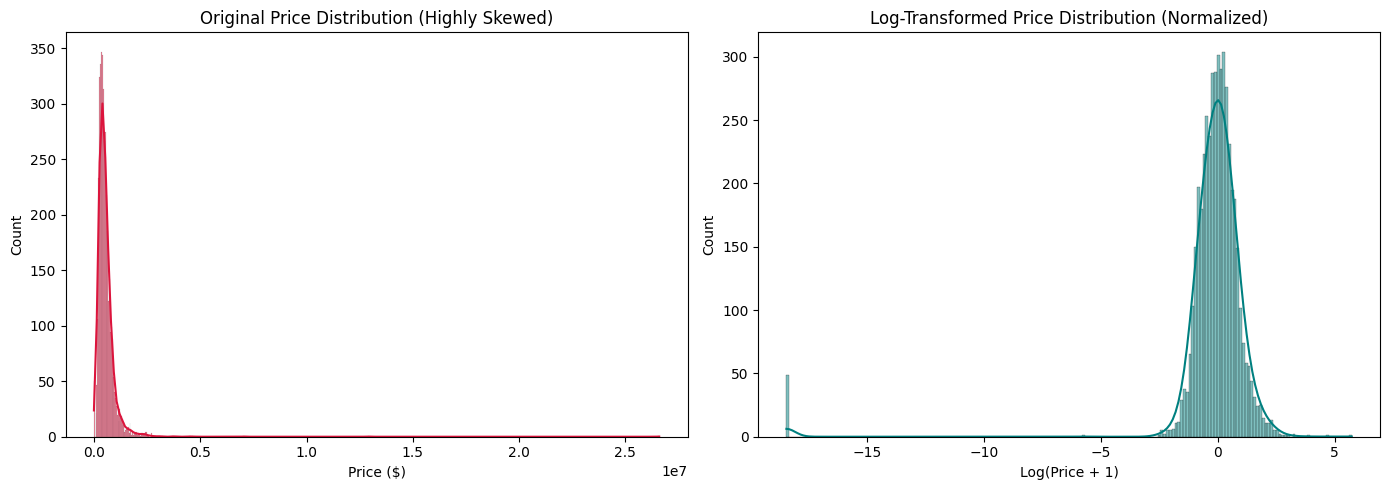

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['price'], kde=True, ax=axes[0], color='crimson')
axes[0].set_title('Original Price Distribution (Highly Skewed)')
axes[0].set_xlabel('Price ($)')

sns.histplot(df_processed['log_price'], kde=True, ax=axes[1], color='teal')
axes[1].set_title('Log-Transformed Price Distribution (Normalized)')
axes[1].set_xlabel('Log(Price + 1)')

plt.tight_layout()
plt.show()

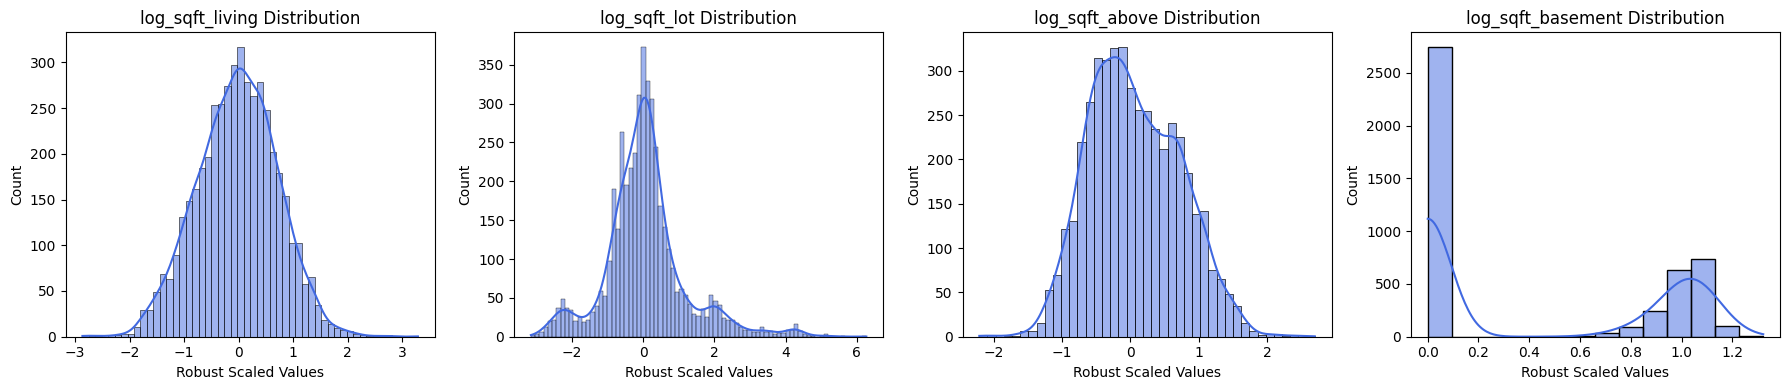

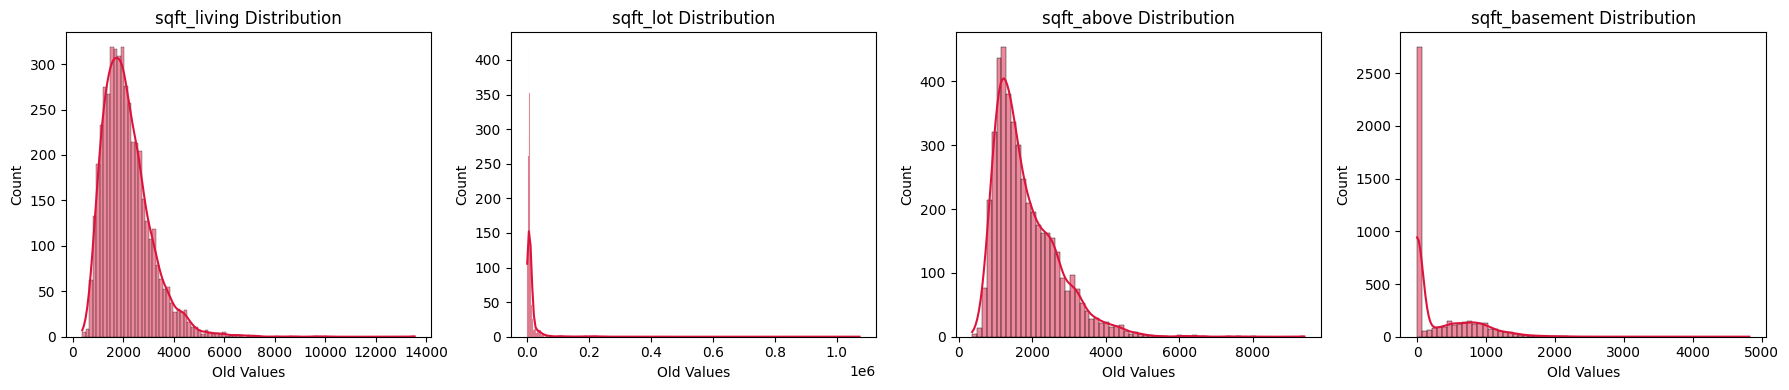

In [ ]:
continuous_features = ['log_sqft_living', 'log_sqft_lot', 'log_sqft_above', 'log_sqft_basement']
old_continous_features = ['sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for i, col in enumerate(continuous_features):
    sns.histplot(df_processed[col], kde=True, ax=axes[i], color='royalblue')
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel('Robust Scaled Values')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for i, col in enumerate(old_continous_features):
    sns.histplot(df[col], kde=True, ax=axes[i], color='crimson')
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel('Old Values')
plt.tight_layout()
plt.show()

/tmp/ipykernel_831/750601349.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], ax=axes[i], palette='Blues_d')
/tmp/ipykernel_831/750601349.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], ax=axes[i], palette='Blues_d')
/tmp/ipykernel_831/750601349.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], ax=axes[i], palette='Blues_d')


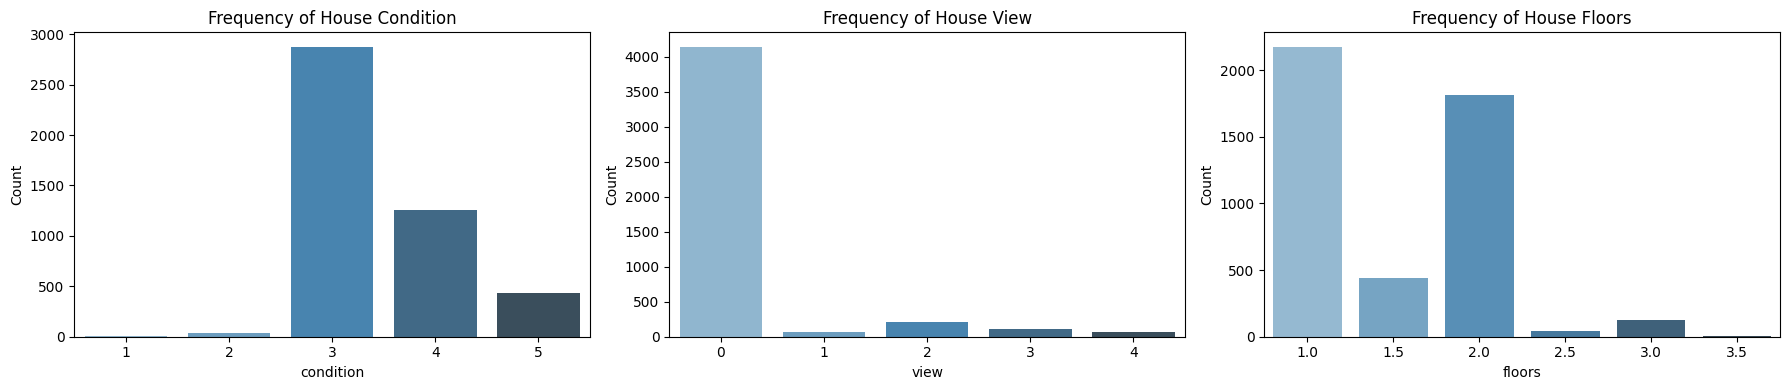

In [ ]:
ordinal_features = ['condition', 'view', 'floors']

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for i, col in enumerate(ordinal_features):
    sns.countplot(x=df[col], ax=axes[i], palette='Blues_d')
    axes[i].set_title(f'Frequency of House {col.capitalize()}')
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

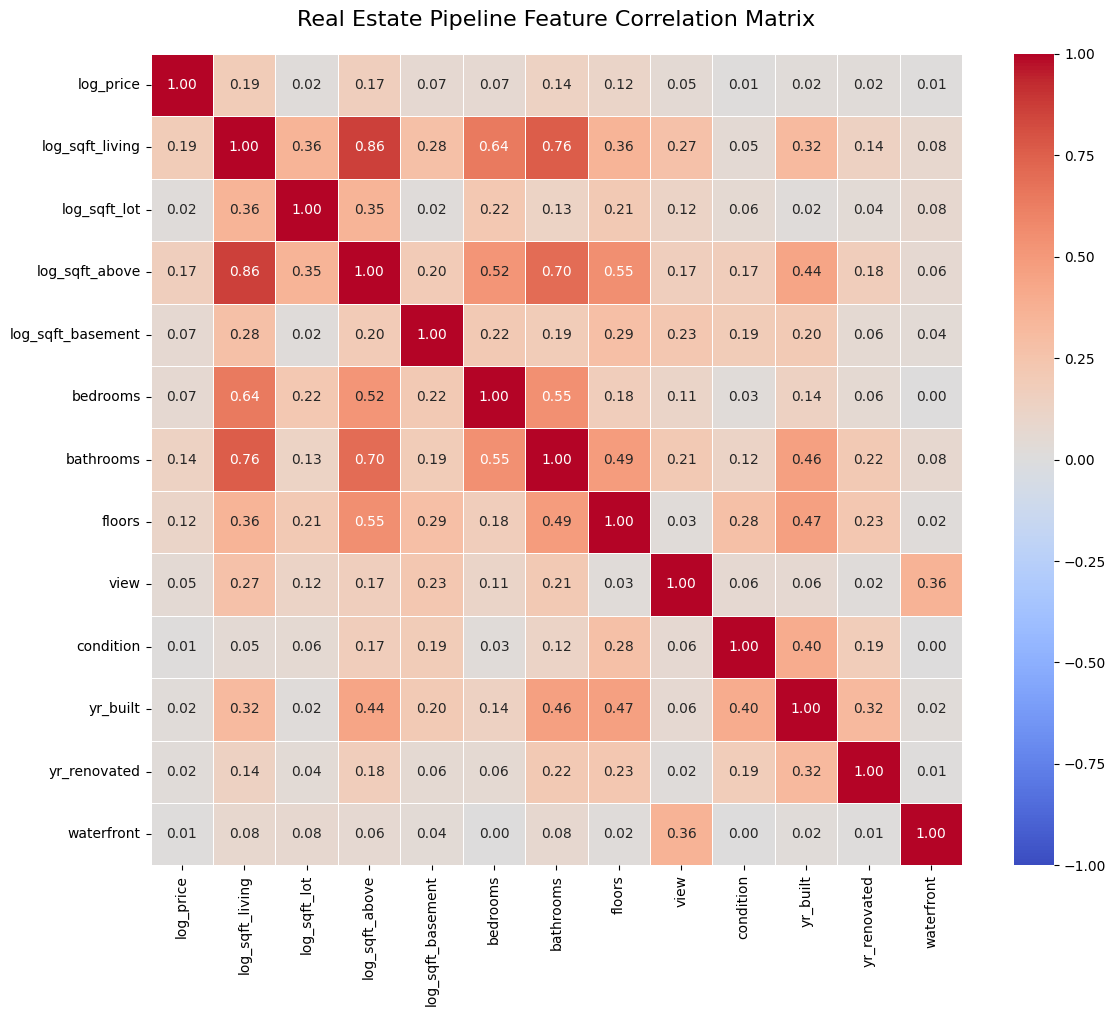

In [ ]:
columns_to_plot = [
    'log_price', 'log_sqft_living', 'log_sqft_lot', 'log_sqft_above',
    'log_sqft_basement', 'bedrooms', 'bathrooms', 'floors',
    'view', 'condition', 'yr_built', 'yr_renovated', 'waterfront'
]
valid_columns = [col for col in columns_to_plot if col in df_processed.columns]
corr_data = df_processed[valid_columns].corr().abs()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_data,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True
)

plt.title('Real Estate Pipeline Feature Correlation Matrix', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files
export_data= df_processed.to_csv("data_processed.csv", index=False)
files.download("data_processed.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pickle as pk
with open('robust_scaler.pkl', 'wb') as f:
    pk.dump(scale, f)
files.download('robust_scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>